# LightGBM Classifier

In this notebook, we train and evaluate a **LightGBM binary classifier** to predict whether player 1 wins a tennis match.

The workflow follows the same chronological logic used for the other classifiers in the project: the data is kept in time order, hyperparameters are selected using **temporal cross-validation**, and the selected model is then evaluated on the separate 2023 validation set.

The important point is that the goal is not simply to obtain a high score on randomly mixed data. A tennis prediction model is intended to predict future matches, so the evaluation should reproduce that situation: the model can use information from the past, but it must not use information from the future.

In [ ]:
# Import the libraries and project functions needed for loading the data,
# preprocessing the features, performing temporal cross-validation, training
# LightGBM, and evaluating the resulting predictions.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import (
    fit_preprocessor,
    transform_data,
    categorical_features,
    numeric_features
)

from src.temporal_cv import validation_years, create_temporal_folds
from src.evaluation import evaluate_model

from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [ ]:
# we load the feature dataset created previously and reorder it
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = PROCESSED_DATA_DIR / "feature_split_matches.csv"

matches = pd.read_csv(
    input_file,
    parse_dates=["Date"]
)

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)

print(matches["DataSplit"].value_counts())

Dataset shape: (26536, 53)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [ ]:
# create copies of the predefined splits
train_data = matches.loc[
    matches["DataSplit"] == "Training"
].copy()

validation_data = matches.loc[
    matches["DataSplit"] == "Validation"
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

# check the time range of each split
print(
    "Training:",
    train_data["Date"].min(),
    "-",
    train_data["Date"].max()
)

print(
    "Validation:",
    validation_data["Date"].min(),
    "-",
    validation_data["Date"].max()
)

print(
    "Test:",
    test_data["Date"].min(),
    "-",
    test_data["Date"].max()
)


assert (
    train_data["Date"].max() < validation_data["Date"].min()
)

assert (
    validation_data["Date"].max() < test_data["Date"].min()
)

print("Chronological order is maintained.")

Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validation: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Test: 2024-01-01 00:00:00 - 2025-11-16 00:00:00
Chronological order is maintained.


In [ ]:
print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Raw selected features:",
    len(numeric_features) + len(categorical_features)
)

Numerical features: 30
Categorical features: 5
Raw selected features: 35


In [ ]:
# create temporal cross-validation folds used for hyperparameter tuning
temporal_folds = create_temporal_folds(
    train_data,
    validation_years
)

print(
    "Number of temporal folds:",
    len(temporal_folds)
)

pd.DataFrame(temporal_folds)

Number of temporal folds: 4


,Fold,TrainingMatches,ValidationMatches,TrainingStartYear,TrainingEndYear,ValidationYear
0,1,10135,2497,2015,2018,2019
1,2,12632,1231,2015,2019,2020
2,3,13863,2402,2015,2020,2021
3,4,16265,2545,2015,2021,2022


### Define hyperparameter configurations

Before training the models, we define the combinations of hyperparameters that will be compared.

The tuning focuses on three parameters:

- **num_leaves** controls the complexity of each tree. More leaves allow the model to learn more detailed patterns, but can also make it more complex.
- **n_estimators** controls how many boosting trees are built.
- **learning_rate** controls how much each new tree contributes to the model.

The combinations are deliberately limited to a small grid so that the comparison remains manageable while still testing different levels of model complexity and boosting strength.

The best configuration will be chosen from the temporal cross-validation results rather than from the final validation set. This keeps the 2023 validation set separate from the hyperparameter-selection process.

In [ ]:
# Define the LightGBM configurations that will be compared during temporal CV.
configurations = [
    {
        "name": "LightGBM leaves 7 est 100 lr 0.05",
        "num_leaves": 7,
        "n_estimators": 100,
        "learning_rate": 0.05
    },

    {
        "name": "LightGBM leaves 7 est 200 lr 0.05",
        "num_leaves": 7,
        "n_estimators": 200,
        "learning_rate": 0.05
    },

    {
        "name": "LightGBM leaves 7 est 100 lr 0.10",
        "num_leaves": 7,
        "n_estimators": 100,
        "learning_rate": 0.10
    },

    {
        "name": "LightGBM leaves 7 est 200 lr 0.10",
        "num_leaves": 7,
        "n_estimators": 200,
        "learning_rate": 0.10
    },

    {
        "name": "LightGBM leaves 15 est 100 lr 0.05",
        "num_leaves": 15,
        "n_estimators": 100,
        "learning_rate": 0.05
    },

    {
        "name": "LightGBM leaves 15 est 200 lr 0.05",
        "num_leaves": 15,
        "n_estimators": 200,
        "learning_rate": 0.05
    },

    {
        "name": "LightGBM leaves 15 est 100 lr 0.10",
        "num_leaves": 15,
        "n_estimators": 100,
        "learning_rate": 0.10
    },

    {
        "name": "LightGBM leaves 15 est 200 lr 0.10",
        "num_leaves": 15,
        "n_estimators": 200,
        "learning_rate": 0.10
    }
]

print(
    "Configurations:",
    len(configurations)
)

Configurations: 8


For every hyperparameter configuration, we train and evaluate one LightGBM model for each temporal fold.

A key detail is that the preprocessing is **fitted separately inside every fold**. The medians, categorical modes, and encoder are learned only from that fold's training data and are then applied to its validation data.

This prevents information from the validation period from influencing preprocessing. In other words, the validation year is treated as genuinely unseen data.

The model is then trained on the transformed historical matches and evaluated on the following year. We store the metrics for every configuration/fold combination so that the configurations can later be compared using their average performance.

In [ ]:
# Store one result for each configuration and temporal fold.
lightgbm_cv_results = []

for configuration in configurations:

    print("Testing:", configuration["name"])

    for fold in temporal_folds:
        fold_number = (fold["Fold"])
        validation_year = (fold["ValidationYear"])

        # use all years before the current validation year for training
        fold_train = train_data.loc[
            train_data["Date"].dt.year < validation_year
        ].copy()

        # use the current year as the validation period
        fold_validation = train_data.loc[
            train_data["Date"].dt.year == validation_year
        ].copy()

        (
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        ) = fit_preprocessor(
            fold_train
        )

        X_fold_train = transform_data(
            fold_train,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )

        X_fold_validation = transform_data(
            fold_validation,
            fold_numeric_medians,
            fold_categorical_modes,
            fold_encoder
        )

        # Player1Won = 1 -> Player 1 won
        # Player1Won = 0 -> Player 2 won
        y_fold_train = (fold_train["Player1Won"].to_numpy())
        y_fold_validation = (fold_validation["Player1Won"].to_numpy())

        # create model
        current_model = LGBMClassifier(
            num_leaves=configuration["num_leaves"], # Control the complexity of the trees
            n_estimators=configuration["n_estimators"], # Number of trees
            learning_rate=configuration["learning_rate"],
            objective="binary",
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        current_model.fit(
            X_fold_train,
            y_fold_train
        )

        # predicted winner for every validation match
        current_predictions = (
            current_model.predict(X_fold_validation)
        )

        # probability assigned to Player 1 winning
        current_probabilities = (
            current_model.predict_proba(X_fold_validation)[:, 1]
        )

        # calculate all evaluation metrics for this fold
        current_fold_results = (
            evaluate_model(
                y_true = y_fold_validation,
                y_pred = current_predictions,
                model_name = configuration["name"],
                y_probability = current_probabilities
            )
        )

        # evaluate_model returns one-row DataFrame;
        # convert that row to a dictionary so extra information can be added
        current_fold_result = (
            current_fold_results.iloc[0].to_dict()
        )

        current_fold_result["Fold"] = fold_number
        current_fold_result["ValidationYear"] = validation_year

        current_fold_result["NumLeaves"] = configuration["num_leaves"]
        current_fold_result["NEstimators"] = configuration["n_estimators"]
        current_fold_result["LearningRate"] = configuration["learning_rate"]

        lightgbm_cv_results.append(current_fold_result)

        print(
            "  Fold",
            fold_number,
            "-",
            validation_year,
            "- Accuracy:",
            round(current_fold_result["Accuracy"],4)
        )

Testing: LightGBM leaves 7 est 100 lr 0.05
  Fold 1 - 2019 - Accuracy: 0.6364
  Fold 2 - 2020 - Accuracy: 0.6279
  Fold 3 - 2021 - Accuracy: 0.6428
  Fold 4 - 2022 - Accuracy: 0.6578
Testing: LightGBM leaves 7 est 200 lr 0.05
  Fold 1 - 2019 - Accuracy: 0.6336
  Fold 2 - 2020 - Accuracy: 0.6401
  Fold 3 - 2021 - Accuracy: 0.6482
  Fold 4 - 2022 - Accuracy: 0.6578
Testing: LightGBM leaves 7 est 100 lr 0.10
  Fold 1 - 2019 - Accuracy: 0.6296
  Fold 2 - 2020 - Accuracy: 0.6328
  Fold 3 - 2021 - Accuracy: 0.649
  Fold 4 - 2022 - Accuracy: 0.6534
Testing: LightGBM leaves 7 est 200 lr 0.10
  Fold 1 - 2019 - Accuracy: 0.6247
  Fold 2 - 2020 - Accuracy: 0.6442
  Fold 3 - 2021 - Accuracy: 0.6374
  Fold 4 - 2022 - Accuracy: 0.6495
Testing: LightGBM leaves 15 est 100 lr 0.05
  Fold 1 - 2019 - Accuracy: 0.6276
  Fold 2 - 2020 - Accuracy: 0.6426
  Fold 3 - 2021 - Accuracy: 0.6391
  Fold 4 - 2022 - Accuracy: 0.6527
Testing: LightGBM leaves 15 est 200 lr 0.05
  Fold 1 - 2019 - Accuracy: 0.6227
  Fold

### Collect CV results

The results from all folds are converted into a DataFrame so they can be inspected and summarized.

There are 8 configurations and 4 temporal folds, so we expect:

**8 × 4 = 32 CV experiments**

The assertion checks that no experiment is missing from the results.

In [ ]:
# convert results into DataFrame
lightgbm_cv_fold_results = pd.DataFrame(lightgbm_cv_results)

lightgbm_cv_fold_results

print(
    "Number of CV experiments:",
    len(lightgbm_cv_fold_results)
)

assert(len(lightgbm_cv_fold_results) == len(configurations) * len(temporal_folds))

print("LightGBM CV experiment count correct.")

Number of CV experiments: 32
LightGBM CV experiment count correct.


A single fold can give a misleading impression because performance may change from one year to another.

For this reason, we calculate the mean of the main evaluation metrics across the four temporal folds. We also keep the standard deviation of accuracy to see how much the accuracy changes between folds.

The configurations are then sorted primarily by **mean accuracy**. ROC-AUC is used as the secondary sorting criterion, so that it can break a tie or near-tie in accuracy.

In [ ]:
# calculate mean temporal-CV results
lightgbm_cv_summary = (
    lightgbm_cv_fold_results.groupby([
            "Model",
            "NumLeaves",
            "NEstimators",
            "LearningRate"
        ], as_index=False
    ).agg(
        MeanAccuracy = ("Accuracy", "mean"),
        StdAccuracy = ("Accuracy", "std"),
        MeanBalancedAccuracy = ("BalancedAccuracy", "mean"),
        MeanF1Score = ("F1", "mean"),
        MeanROC_AUC = ("ROC-AUC", "mean"),
        MeanLogLoss = ("LogLoss", "mean")
    )
)

# rank configurations by mean accuracy, using ROC-AUC as a tie-breaker.
lightgbm_cv_summary = lightgbm_cv_summary.sort_values(
    by = ["MeanAccuracy", "MeanROC_AUC"],
    ascending = [False, False]
).reset_index(drop = True)

lightgbm_cv_summary

,Model,NumLeaves,NEstimators,LearningRate,MeanAccuracy,StdAccuracy,MeanBalancedAccuracy,MeanF1Score,MeanROC_AUC,MeanLogLoss
0,LightGBM leaves 7 est 200 lr 0.05,7,200,0.05,0.644915,0.010451,0.644900,0.633054,0.705744,0.622657
1,LightGBM leaves 15 est 200 lr 0.05,15,200,0.05,0.642636,0.014160,0.642694,0.630955,0.699675,0.627283
2,LightGBM leaves 7 est 100 lr 0.05,7,100,0.05,0.641217,0.012595,0.641093,0.625190,0.705488,0.622801
3,LightGBM leaves 7 est 100 lr 0.10,7,100,0.10,0.641214,0.011791,0.641178,0.627323,0.705813,0.622287
4,LightGBM leaves 15 est 100 lr 0.10,15,100,0.10,0.641012,0.014359,0.641295,0.630601,0.700059,0.627508
5,LightGBM leaves 15 est 100 lr 0.05,15,100,0.05,0.640456,0.010355,0.640529,0.624899,0.703915,0.623470
6,LightGBM leaves 7 est 200 lr 0.10,7,200,0.10,0.638959,0.010694,0.638991,0.627029,0.700038,0.627236
7,LightGBM leaves 15 est 200 lr 0.10,15,200,0.10,0.636381,0.015429,0.636472,0.627775,0.691424,0.638275


### Select the best hyperparameter configuration

The first row of the sorted summary corresponds to the configuration with the highest mean temporal-CV accuracy.

We retrieve the complete configuration from the original list so that the exact hyperparameters can be used when training the final selected model.


In [ ]:
# select the configuration with the best mean temporal-CV accuracy
best_model_name = lightgbm_cv_summary.iloc[0]["Model"]

print("Selected LightGBM:", best_model_name)

best_configuration = next(
    configuration
    for configuration in configurations
    if configuration["name"] == best_model_name
)

best_configuration

Selected LightGBM: LightGBM leaves 7 est 200 lr 0.05


{'name': 'LightGBM leaves 7 est 200 lr 0.05',
 'num_leaves': 7,
 'n_estimators': 200,
 'learning_rate': 0.05}

### Fit preprocessing on the complete training period

After selecting the hyperparameters, we can prepare the final training/validation experiment.

Here the preprocessing is fitted using **all of the training data** (2015–2022).

The same preprocessing objects are then applied to the separate 2023 validation data. 

The target is `Player1Won`, where 1 represents a Player 1 win and 0 represents a Player 2 win.

Finally, the assertions check that preprocessing has removed all missing values from the matrices passed to LightGBM.

In [ ]:
# fit preprocessing using the complete training period
(
    numeric_medians,
    categorical_modes,
    one_hot_encoder
) = fit_preprocessor(
    train_data
)

X_train = transform_data(
    train_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

X_validation = transform_data(
    validation_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

# target values
y_train = (train_data["Player1Won"].to_numpy())
y_validation = (validation_data["Player1Won"].to_numpy())

print("Training X:", X_train.shape)
print("Validation X:", X_validation.shape)

print("Training y:", y_train.shape)
print("Validation y:", y_validation.shape)

# preprocessing should leave no missing values
assert (X_train.isna().sum().sum() == 0)
assert (X_validation.isna().sum().sum() == 0)

print("LightGBM preprocessing check passed.")

Training X: (18810, 50)
Validation X: (2607, 50)
Training y: (18810,)
Validation y: (2607,)
LightGBM preprocessing check passed.


We now instantiate LightGBM using the hyperparameters selected through temporal cross-validation.

The objective is set to `"binary"` because the target has two possible outcomes: Player 1 wins or Player 2 wins.

`random_state=42` makes the experiment reproducible, while `n_jobs=-1` allows LightGBM to use the available CPU cores.

In [ ]:
# create the final LightGBM model
best_lightgbm = LGBMClassifier(
    num_leaves=best_configuration["num_leaves"],
    n_estimators=best_configuration["n_estimators"],
    learning_rate=best_configuration["learning_rate"],
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [ ]:
# train on the complete training period 2015-2022
best_lightgbm.fit(
    X_train,
    y_train
)

,num_leaves,7
,learning_rate,0.05
,n_estimators,200
,objective,'binary'
,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None


### Evaluation

The trained model produces two useful types of output.

`predict()` gives the final predicted class for each match: 0 for Player 2 and 1 for Player 1.

`predict_proba()` gives probabilities for the two classes. Selecting `[:, 1]` keeps the probability assigned to class 1, i.e. the probability that **Player 1 wins**.

We keep both because classification metrics such as accuracy and F1 use the predicted classes, while metrics such as ROC-AUC and LogLoss use the predicted probabilities.

The classification report provides a more detailed view of precision, recall, and F1 for both possible winners.

In [ ]:
# returns predicted classes [0, 1, 1, 0, 1, ...]
best_validation_predictions = (
    best_lightgbm.predict(X_validation)
)

# returns probabilities that player 1 wins [0.23, 0.81, ...]
best_validation_probabilities = (
    best_lightgbm.predict_proba(X_validation)[:, 1] 
) 

# compares true validation labels against predicted validation labels
print(
    classification_report(
        y_validation, 
        best_validation_predictions, 
        target_names=["Player 2 wins", "Player 1 wins"], 
        zero_division=0
    ) 
)

In [ ]:
# Calculate the complete set of evaluation metrics for the selected model
# on the external validation period.
best_lightgbm_result = evaluate_model(
    y_true = y_validation,
    y_pred = (best_validation_predictions),
    model_name = (best_model_name),
    y_probability = (best_validation_probabilities)
)

best_lightgbm_result

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC-AUC,LogLoss
0,LightGBM leaves 7 est 200 lr 0.05,0.63598,0.636209,0.61171,0.640839,0.625936,0.701624,0.624024


The confusion matrix shows how the validation matches are distributed between correct and incorrect predictions for the two classes.

Unlike a single accuracy value, it lets us see which winner class is being predicted correctly and where the model is making mistakes.

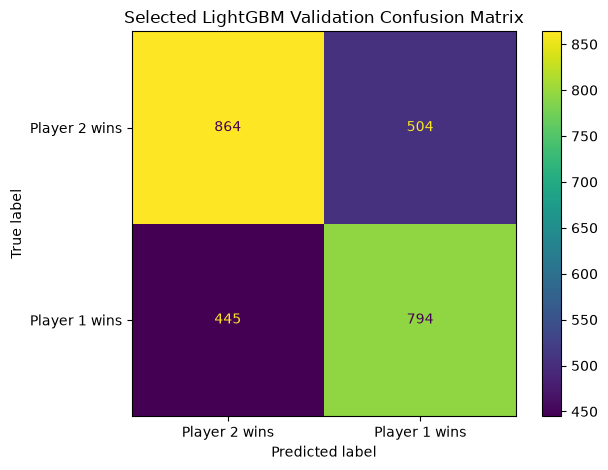

In [ ]:
# Display the validation confusion matrix to inspect correct and incorrect predictions for each winner class.
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    best_validation_predictions,
    display_labels = ["Player 2 wins", "Player 1 wins"],
    values_format = "d"
)

plt.title("Selected LightGBM Validation Confusion Matrix")

plt.tight_layout()

plt.show()

### Feature importance

LightGBM provides feature-importance values for the fitted model.

Here we combine the feature names with their importance values and sort them from most to least important.

Feature importance should be interpreted as information about the model's use of the features; it does not by itself prove that a feature causes the outcome.

In [ ]:
# extract and sort the feature-importance values provided by the fitted model
# so that the most influential input features can be inspected.
lightgbm_feature_importance = pd.DataFrame(
    {
        "Feature":X_train.columns,
        "Importance":best_lightgbm.feature_importances_
    }
)

lightgbm_feature_importance = (
    lightgbm_feature_importance.sort_values(
        by="Importance",
        ascending=False
    ).reset_index(drop=True)
)

lightgbm_feature_importance

,Feature,Importance
0,PointsDifference,146
1,SurfaceWinRateDifference,74
2,ExperienceDifference,71
3,RankDifference,70
4,Player2SurfaceMatchesBefore,69
5,Recent5WinRateDifference,64
6,Player1SurfaceMatchesBefore,60
7,DaysSinceLastMatchDifference,55
8,Player2SurfaceWinRateBefore,45
9,Player2MatchesBefore,44


In [ ]:
# we show the top 15 features
print("Top 15 LightGBM features:")

print(lightgbm_feature_importance.head(15))

Top 15 LightGBM features:
                         Feature  Importance
0               PointsDifference         146
1       SurfaceWinRateDifference          74
2           ExperienceDifference          71
3                 RankDifference          70
4    Player2SurfaceMatchesBefore          69
5       Recent5WinRateDifference          64
6    Player1SurfaceMatchesBefore          60
7   DaysSinceLastMatchDifference          55
8    Player2SurfaceWinRateBefore          45
9           Player2MatchesBefore          44
10             WinRateDifference          44
11      SurfaceMatchesDifference          44
12                 Player1Points          43
13                 Player2Points          41
14          Player1WinRateBefore          39


The top 15 features are sorted in ascending order before plotting so that the most important feature appears at the top of the horizontal bar chart.

The plot provides a quicker visual comparison of the relative importance values than the table alone.

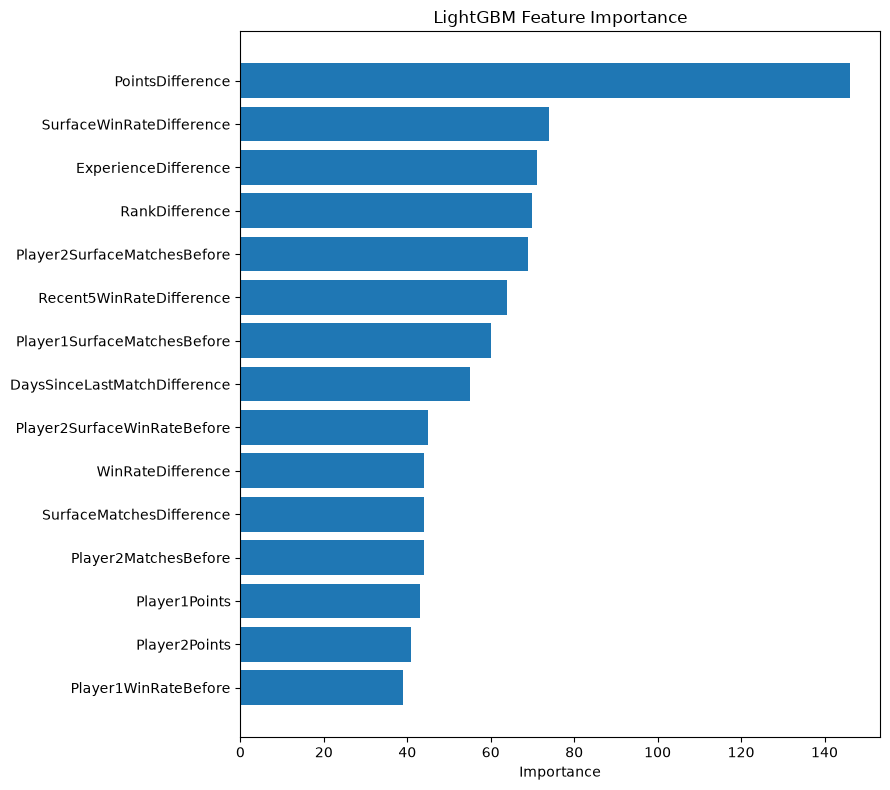

In [ ]:
# plot the top 15 features 
top_features = (
    lightgbm_feature_importance
    .head(15)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(figsize=(9, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")

plt.title("LightGBM Feature Importance")

plt.tight_layout()

plt.show()

### Comparing the tuning conifgurations

This table presents the main hyperparameter settings together with their temporal-CV performance.

Looking at the table makes it possible to compare not only the mean accuracy used for selection, but also the variability of accuracy and the probability-based metrics such as ROC-AUC and LogLoss.

In [ ]:
# tuning results table
lightgbm_cv_summary[
    [
        "NumLeaves",
        "NEstimators",
        "LearningRate",
        "MeanAccuracy",
        "StdAccuracy",
        "MeanROC_AUC",
        "MeanLogLoss"
    ]
]

,NumLeaves,NEstimators,LearningRate,MeanAccuracy,StdAccuracy,MeanROC_AUC,MeanLogLoss
0,7,200,0.05,0.644915,0.010451,0.705744,0.622657
1,15,200,0.05,0.642636,0.014160,0.699675,0.627283
2,7,100,0.05,0.641217,0.012595,0.705488,0.622801
3,7,100,0.10,0.641214,0.011791,0.705813,0.622287
4,15,100,0.10,0.641012,0.014359,0.700059,0.627508
5,15,100,0.05,0.640456,0.010355,0.703915,0.623470
6,7,200,0.10,0.638959,0.010694,0.700038,0.627236
7,15,200,0.10,0.636381,0.015429,0.691424,0.638275


The plot below gives a visual comparison of the mean temporal-CV accuracy for all tested configurations.

The x-axis is given a small amount of padding so that the differences between configurations can be read more clearly. The exact accuracy is also written next to each bar.

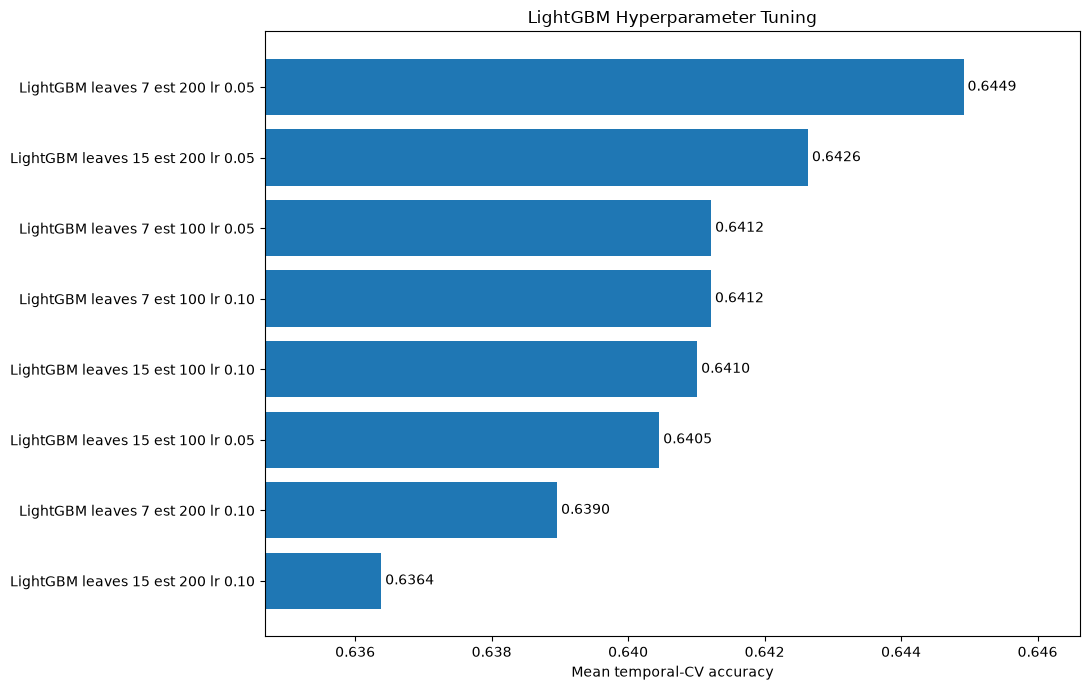

In [ ]:
# we create a horizontal bar chart to compare the mean accuracy tested during hyperparameter tuning
plot_data = lightgbm_cv_summary.sort_values(
    "MeanAccuracy",
    ascending=True
)

# we determine the range of the x-axis
min_accuracy = plot_data["MeanAccuracy"].min()
max_accuracy = plot_data["MeanAccuracy"].max()

# how much the accuracies vary between the worst and best configurations
difference = max_accuracy - min_accuracy

padding = max(
    difference * 0.20,
    0.001
)

# create the plotting area
plt.figure(figsize=(11, 7))

bars = plt.barh(
    plot_data["Model"],
    plot_data["MeanAccuracy"]
)

plt.xlim(
    min_accuracy - padding,
    max_accuracy + padding
)

plt.xlabel("Mean temporal-CV accuracy")

plt.title("LightGBM Hyperparameter Tuning")

# add accuracy for every bar
for bar, value in zip (
    bars,
    plot_data["MeanAccuracy"]
):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va = "center"
    )

plt.tight_layout()

plt.show()

In [ ]:
# define output directories and save the experiment results for final analysis
MODEL_SELECTION_RESULTS_DIR = Path("../results/model_selection")

VALIDATION_RESULTS_DIR = Path("../results/validation")

FEATURE_IMPORTANCE_RESULTS_DIR = Path("../results/feature_importance")

MODELS_DIR = Path("../models")

The fold-level CV results, the aggregated tuning summary, the 2023 validation metrics, and the feature-importance table are saved as CSV files.

We'll need these later.

In [ ]:
# save evaluation outputs
lightgbm_cv_fold_results.to_csv(
    MODEL_SELECTION_RESULTS_DIR /"lightgbm_cv_fold_results.csv",
    index=False
)

lightgbm_cv_summary.to_csv(
    MODEL_SELECTION_RESULTS_DIR /"lightgbm_cv_tuning_summary.csv",
    index=False
)

# save validation result
best_lightgbm_result.to_csv(
    VALIDATION_RESULTS_DIR / "best_lightgbm_result.csv",
    index=False
)

# save feature importance
lightgbm_feature_importance.to_csv(
    FEATURE_IMPORTANCE_RESULTS_DIR /"lightgbm_feature_importance.csv",
    index=False
)

### Save trained model

This allows the exact trained model to be loaded later for prediction without retraining it from scratch.

In [ ]:
# save the fitted LightGBM model so it can be loaded later without retraining.
import joblib

joblib.dump(
    best_lightgbm,
    MODELS_DIR /"best_lightgbm_validation.joblib"
)

['..\\models\\best_lightgbm_validation.joblib']

### Save preprocessing objects

Later we can reproduce exactly the same transformation.

In [ ]:
# save preprocessing objects together with the model
lightgbm_preprocessing = {
    "numeric_medians":numeric_medians,
    "categorical_modes": categorical_modes,
    "one_hot_encoder": one_hot_encoder
}

joblib.dump(
    lightgbm_preprocessing,
    MODELS_DIR /"lightgbm_preprocessing.joblib"
)

['..\\models\\lightgbm_preprocessing.joblib']

### Final summary

The final cell collects the main results of the LightGBM experiment in one place:

1. the temporal-CV comparison of all configurations,
2. the selected hyperparameters,
3. the performance on the separate 2023 validation period, and
4. the 15 most important features.

This provides a compact overview of the complete model-selection and evaluation process.


In [ ]:
# final overview of the experiment
print("LIGHTGBM TEMPORAL CV")
print( lightgbm_cv_summary)

print("\nSelected configuration:")
print( best_configuration)

print("\nExternal 2023 validation:")

print(best_lightgbm_result)

print("\nTop 15 features:")

print(lightgbm_feature_importance.head(15))

LIGHTGBM TEMPORAL CV
                                Model  NumLeaves  NEstimators  LearningRate  \
0   LightGBM leaves 7 est 200 lr 0.05          7          200          0.05   
1  LightGBM leaves 15 est 200 lr 0.05         15          200          0.05   
2   LightGBM leaves 7 est 100 lr 0.05          7          100          0.05   
3   LightGBM leaves 7 est 100 lr 0.10          7          100          0.10   
4  LightGBM leaves 15 est 100 lr 0.10         15          100          0.10   
5  LightGBM leaves 15 est 100 lr 0.05         15          100          0.05   
6   LightGBM leaves 7 est 200 lr 0.10          7          200          0.10   
7  LightGBM leaves 15 est 200 lr 0.10         15          200          0.10   

   MeanAccuracy  StdAccuracy  MeanBalancedAccuracy  MeanF1Score  MeanROC_AUC  \
0      0.644915     0.010451              0.644900     0.633054     0.705744   
1      0.642636     0.014160              0.642694     0.630955     0.699675   
2      0.641217     0.01259